# Solutions to Process 9
Investigate the validity of the proposed $\{PPB, \tau_\alpha\}$ system solved for $\{T_e, n_e\}$.

Check impact of various core radiation model assumptions.

In [24]:
# Reload Process each time (keep editable install up-to-date)
%load_ext autoreload
%autoreload 2
from IPython.display import clear_output
from process.main import SingleRun
import process.data_structure
import process.impurity_radiation as impurity_radiation
import process.constraints
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from process.io.plot_solutions import (
    RunMetadata,
    plot_mfile_solutions,
    plot_mfile_solutions_constraints,
)
from pathlib import Path

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Set up
Same as in `solutions_to_process_2.ipynb`.

## Core radiation model assumptions
Investigate the effect on radiation and the plasma power balance solutions of 3 different radiation model modifications:
- Removal of core radiation reduction
- Inclusion of edge radiation in the PPB
- Integrating the edge radiation

Plot the effects of these against a varying tungsten fraction.

## Evaluating core and edge radiation

In [ ]:
w_fracs = np.linspace(5.0e-6, 4.0e-5, 5)
sol_data = {
    "run": [],
    "w": [],
    "rad_core": [],
    "rad_edge": [],
    "rad_total": [],
    "ppb": [],
    "imp_rad_total": [],
    "imp_rad_core": [],
    "imp_rad_edge": [],
}
INPUT_FILE = "data/lt_tau_alpha_sol_eval_IN.DAT"
runs = [
    "original",
    "rho fix",
    "rho fix, no core rad reduction",
    "rho fix, no core rad reduction, edge integral",
    "rho fix, no core rad reduction, edge integral, edge in PPB",
]
for run in runs:
    for w_frac in w_fracs:
        # Solve Process each time after modifying W fraction
        single_run = SingleRun(INPUT_FILE)
        process.data_structure.impurity_radiation_module.f_nd_impurity_electron_array[
            13
        ] = w_frac

        # Modifications for each run
        # Try to get results for sensible te, ne and W
        process.data_structure.physics_variables.te = 13.0
        process.data_structure.physics_variables.dene = 4.0e19
        if run == "original":
            pass
        elif run == "rho fix":
            # Use rho fix
            impurity_radiation.rho_fix = True
        elif run == "rho fix, no core rad reduction":
            impurity_radiation.rho_fix = True
            # No core rad reduction
            process.data_structure.impurity_radiation_module.f_p_plasma_core_rad_reduction = 1.0
        elif run == "rho fix, no core rad reduction, edge integral":
            impurity_radiation.rho_fix = True
            process.data_structure.impurity_radiation_module.f_p_plasma_core_rad_reduction = 1.0
            # Use new edge integral
            impurity_radiation.int_edge_rad = True
        elif run == "rho fix, no core rad reduction, edge integral, edge in PPB":
            impurity_radiation.rho_fix = True
            process.data_structure.impurity_radiation_module.f_p_plasma_core_rad_reduction = 1.0
            impurity_radiation.int_edge_rad = True
            # Include edge rad in PPB
            process.data_structure.physics_variables.i_rad_loss = 0

        try:
            # Handle failed runs
            single_run.run()
        except Exception:
            # Insert nans for everything on failure, then add back inputs
            for key in sol_data.keys():
                sol_data[key].append(np.nan)
            sol_data["run"][-1] = run
            sol_data["w"][-1] = w_frac
            continue

        sol_data["run"].append(run)
        sol_data["w"].append(w_frac)
        sol_data["rad_core"].append(
            process.data_structure.physics_variables.p_plasma_inner_rad_mw
        )
        sol_data["rad_edge"].append(
            process.data_structure.physics_variables.p_plasma_outer_rad_mw
        )
        sol_data["rad_total"].append(
            process.data_structure.physics_variables.p_plasma_rad_mw
        )
        sol_data["ppb"].append(
            process.constraints.constraint_equation_2().normalised_residual
        )
        # Debug
        sol_data["imp_rad_total"].append(impurity_radiation.pden_impurity_rad_profile)
        sol_data["imp_rad_core"].append(
            impurity_radiation.pden_impurity_core_rad_profile
        )
        sol_data["imp_rad_edge"].append(
            impurity_radiation.pden_impurity_rad_edge_profile
        )

# Clear the lengthy stdout from multiple process runs
clear_output()

sol_df = pd.DataFrame(sol_data)

In [4]:
sol_df = pd.DataFrame(sol_data)
sol_df

,run,w,rad_core,rad_edge,rad_total,ppb,imp_rad_total,imp_rad_core,imp_rad_edge
0,original,0.000005,17.294798,79.312585,96.607383,0.124957,"[0.0, 6.4239651609378505, 12.849083295809786, ...","[0.0, 3.85437909656271, 7.70944997748587, 11.5...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,original,0.000014,17.803322,83.481675,101.284997,0.124030,"[0.0, 6.6346809618851506, 13.2705573967191, 19...","[0.0, 3.9808085771310897, 7.962334438031459, 1...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,original,0.000023,18.311846,87.650765,105.962611,0.123104,"[0.0, 6.845396876953071, 13.692031725890217, 2...","[0.0, 4.1072381261718425, 8.21521903553413, 12...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,original,0.000031,18.820370,91.819856,110.640225,0.122179,"[0.0, 7.056112907472925, 14.113506285986006, 2...","[0.0, 4.233667744483755, 8.468103771591602, 12...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,original,0.000040,19.328894,95.988947,115.317841,0.121254,"[0.0, 7.266829054774354, 14.53498107966598, 21...","[0.0, 4.360097432864612, 8.720988647799587, 13...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
5,rho fix,0.000005,26.498027,93.790465,120.288492,0.105771,"[3212.220226800738, 3212.3163152357106, 3212.6...","[1927.3321360804428, 1927.3897891414263, 1927....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
6,rho fix,0.000014,27.401020,98.668675,126.069695,0.104051,"[3317.5910692330167, 3317.69069960558, 3317.98...","[1990.5546415398098, 1990.614419763348, 1990.7...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
7,rho fix,0.000023,28.304014,103.546889,131.850902,0.102333,"[3422.962174073957, 3423.0653463919916, 3423.3...","[2053.7773044443743, 2053.839207835195, 2054.0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
8,rho fix,0.000031,29.207009,108.425106,137.632115,0.100619,"[3528.3335455687006, 3528.440259840213, 3528.7...","[2117.0001273412204, 2117.064155904128, 2117.2...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
9,rho fix,0.000040,30.110005,113.303327,143.413332,0.098908,"[3633.705188044958, 3633.8154442780856, 3634.1...","[2180.2231128269746, 2180.2892665668514, 2180....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


### Plot profiles

Text(0.5, 0, '$\\rho$')

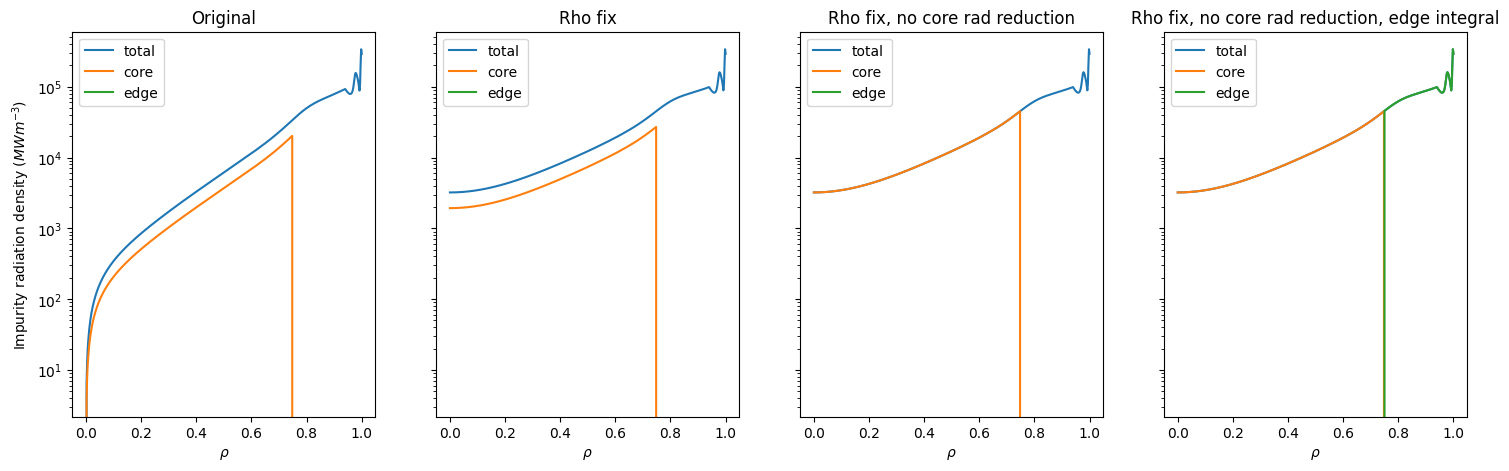

In [7]:
%matplotlib inline
fig, ax = plt.subplots(ncols=4, sharey=True)
fig.set_size_inches(18, 5)
# Original
total = sol_df[(sol_df["run"] == "original") & (sol_df["w"] == 5e-6)][
    "imp_rad_total"
].to_numpy()[0]
core = sol_df[(sol_df["run"] == "original") & (sol_df["w"] == 5e-6)][
    "imp_rad_core"
].to_numpy()[0]
edge = sol_df[(sol_df["run"] == "original") & (sol_df["w"] == 5e-6)][
    "imp_rad_edge"
].to_numpy()[0]
x = np.linspace(0, 1, len(total))
ax[0].plot(x, total, label="total")
ax[0].plot(x, core, label="core")
ax[0].plot(x, edge, label="edge")
ax[0].legend()
ax[0].set_yscale("log")
ax[0].set_title("Original")
ax[0].set_ylabel("Impurity radiation density ($MW m^{-3}$)")
ax[0].set_xlabel(r"$\rho$")

# rho fix
total = sol_df[(sol_df["run"] == "rho fix") & (sol_df["w"] == 5e-6)][
    "imp_rad_total"
].to_numpy()[0]
core = sol_df[(sol_df["run"] == "rho fix") & (sol_df["w"] == 5e-6)][
    "imp_rad_core"
].to_numpy()[0]
edge = sol_df[(sol_df["run"] == "rho fix") & (sol_df["w"] == 5e-6)][
    "imp_rad_edge"
].to_numpy()[0]
ax[1].plot(x, total, label="total")
ax[1].plot(x, core, label="core")
ax[1].plot(x, edge, label="edge")
ax[1].legend()
ax[1].set_yscale("log")
ax[1].set_title("Rho fix")
ax[1].set_xlabel(r"$\rho$")

# rho fix, no core rad
total = sol_df[
    (sol_df["run"] == "rho fix, no core rad reduction") & (sol_df["w"] == 5e-6)
]["imp_rad_total"].to_numpy()[0]
core = sol_df[
    (sol_df["run"] == "rho fix, no core rad reduction") & (sol_df["w"] == 5e-6)
]["imp_rad_core"].to_numpy()[0]
edge = sol_df[
    (sol_df["run"] == "rho fix, no core rad reduction") & (sol_df["w"] == 5e-6)
]["imp_rad_edge"].to_numpy()[0]
ax[2].plot(x, total, label="total")
ax[2].plot(x, core, label="core")
ax[2].plot(x, edge, label="edge")
ax[2].legend()
ax[2].set_yscale("log")
ax[2].set_title("Rho fix, no core rad reduction")
ax[2].set_xlabel(r"$\rho$")

# rho fix, no core rad, edge integral
total = sol_df[
    (sol_df["run"] == "rho fix, no core rad reduction, edge integral")
    & (sol_df["w"] == 5e-6)
]["imp_rad_total"].to_numpy()[0]
core = sol_df[
    (sol_df["run"] == "rho fix, no core rad reduction, edge integral")
    & (sol_df["w"] == 5e-6)
]["imp_rad_core"].to_numpy()[0]
edge = sol_df[
    (sol_df["run"] == "rho fix, no core rad reduction, edge integral")
    & (sol_df["w"] == 5e-6)
]["imp_rad_edge"].to_numpy()[0]
ax[3].plot(x, total, label="total")
ax[3].plot(x, core, label="core")
ax[3].plot(x, edge, label="edge")
ax[3].legend()
ax[3].set_yscale("log")
ax[3].set_title("Rho fix, no core rad reduction, edge integral")
ax[3].set_xlabel(r"$\rho$")

This now appears to make sense: the rho factor was incorrectly multiplying the impurity radiation power density.

## Plot radiation totals

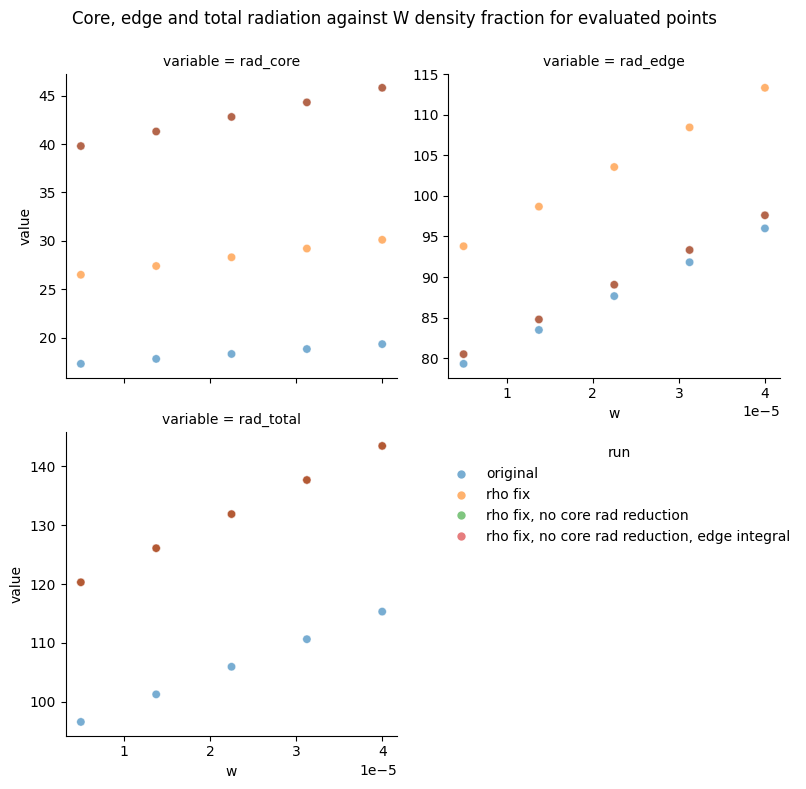

In [9]:
%matplotlib inline
sol_df = pd.DataFrame(sol_data)
rad_tot_df = sol_df.drop(
    columns=["imp_rad_total", "imp_rad_core", "imp_rad_edge", "ppb"]
)
rad_tot_df = rad_tot_df.drop(
    rad_tot_df[
        rad_tot_df["run"]
        == "rho fix, no core rad reduction, edge integral, edge in PPB"
    ].index
)
rad_tot_df_melt = rad_tot_df.melt(id_vars=["w", "run"])

fg = sns.relplot(
    data=rad_tot_df_melt,
    x="w",
    y="value",
    col="variable",
    col_wrap=2,
    facet_kws=dict(sharey=False, legend_out=False),
    height=4,
    aspect=1.0,
    hue="run",
    alpha=0.6,
    # style="run",
)
for axes in fg.axes.flat:
    axes.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))


fg.figure.suptitle(
    r"Core, edge and total radiation against W density fraction for evaluated points"
)
fg.figure.subplots_adjust(top=0.90)
sns.move_legend(fg, loc="upper left", bbox_to_anchor=(0.55, 0.45), frameon=False)

Integrating the edge has no effect. The total radiation is higher.

## Adding in edge radiation to the PPB
Plot the PPB with these modifications, including adding the edge radiation into the PPB.

Text(0.5, 1.0, 'Plasma power balance against tungsten fraction for various radiation modifications.')

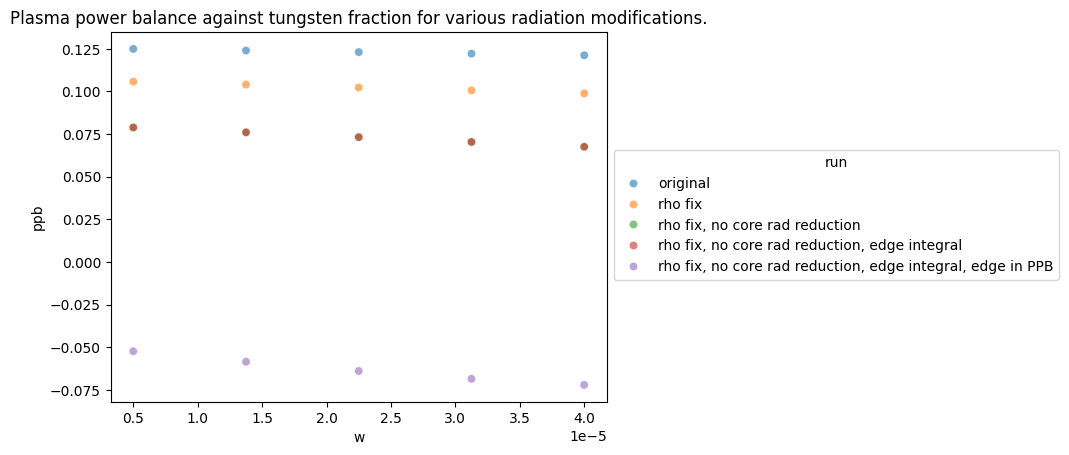

In [11]:
%matplotlib inline
sol_df = pd.DataFrame(sol_data)
ppb_df = sol_df[["w", "run", "ppb"]]

ax = sns.scatterplot(data=ppb_df, x="w", y="ppb", hue="run", alpha=0.6)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 0.7))
ax.set_title(
    "Plasma power balance against tungsten fraction for various radiation modifications."
)

The PPB is affected greatly by the inclusion of the edge radiation.



## Solutions
Now solve the same problems.

In [2]:
w_fracs = np.linspace(5.0e-6, 4.0e-5, 5)
sol_data = {
    "run": [],
    "w": [],
    "rad_core": [],
    "rad_edge": [],
    "rad_total": [],
    "ppb": [],
    "imp_rad_total": [],
    "imp_rad_core": [],
    "imp_rad_edge": [],
    "te": [],
    "ne": [],
    "rad_frac": [],
}
INPUT_FILE = "data/lt_tau_alpha_sol_solve_IN.DAT"
runs = [
    "original",
    "rho fix",
    "rho fix, no core rad reduction",
    "rho fix, no core rad reduction, edge integral",
    "rho fix, no core rad reduction, edge integral, edge in PPB",
]
for run in runs:
    for w_frac in w_fracs:
        # Solve Process each time after modifying W fraction
        single_run = SingleRun(INPUT_FILE)
        process.data_structure.impurity_radiation_module.f_nd_impurity_electron_array[
            13
        ] = w_frac

        # Modifications for each run
        # Try to get results for sensible te, ne and W
        process.data_structure.physics_variables.te = 10.0
        process.data_structure.physics_variables.dene = 4.0e19
        # Try turning up heating
        process.data_structure.current_drive_variables.p_hcd_primary_extra_heat_mw = (
            200.0
        )
        if run == "original":
            impurity_radiation.rho_fix = False
            process.data_structure.impurity_radiation_module.f_p_plasma_core_rad_reduction = 0.6
            impurity_radiation.int_edge_rad = False
            process.data_structure.physics_variables.i_rad_loss = 1
        elif run == "rho fix":
            impurity_radiation.rho_fix = True
            process.data_structure.impurity_radiation_module.f_p_plasma_core_rad_reduction = 0.6
            impurity_radiation.int_edge_rad = False
            process.data_structure.physics_variables.i_rad_loss = 1
        elif run == "rho fix, no core rad reduction":
            # No core rad reduction
            impurity_radiation.rho_fix = True
            process.data_structure.impurity_radiation_module.f_p_plasma_core_rad_reduction = 1.0
            impurity_radiation.int_edge_rad = False
            process.data_structure.physics_variables.i_rad_loss = 1
        elif run == "rho fix, no core rad reduction, edge integral":
            # Use new edge integral
            impurity_radiation.rho_fix = True
            process.data_structure.impurity_radiation_module.f_p_plasma_core_rad_reduction = 1.0
            impurity_radiation.int_edge_rad = True
            process.data_structure.physics_variables.i_rad_loss = 1
        elif run == "rho fix, no core rad reduction, edge integral, edge in PPB":
            # Include edge rad in PPB
            impurity_radiation.rho_fix = True
            process.data_structure.impurity_radiation_module.f_p_plasma_core_rad_reduction = 1.0
            impurity_radiation.int_edge_rad = True
            process.data_structure.physics_variables.i_rad_loss = 0

        try:
            # Handle failed runs
            single_run.run()
        except Exception:
            # Insert nans for everything on failure, then add back inputs
            for key in sol_data.keys():
                sol_data[key].append(np.nan)
            sol_data["run"][-1] = run
            sol_data["w"][-1] = w_frac
            continue

        sol_data["run"].append(run)
        sol_data["w"].append(w_frac)
        sol_data["rad_core"].append(
            process.data_structure.physics_variables.p_plasma_inner_rad_mw
        )
        sol_data["rad_edge"].append(
            process.data_structure.physics_variables.p_plasma_outer_rad_mw
        )
        sol_data["rad_total"].append(
            process.data_structure.physics_variables.p_plasma_rad_mw
        )
        sol_data["ppb"].append(
            process.constraints.constraint_equation_2().normalised_residual
        )
        # Debug
        sol_data["imp_rad_total"].append(impurity_radiation.pden_impurity_rad_profile)
        sol_data["imp_rad_core"].append(
            impurity_radiation.pden_impurity_core_rad_profile
        )
        sol_data["imp_rad_edge"].append(
            impurity_radiation.pden_impurity_rad_edge_profile
        )
        sol_data["te"].append(process.data_structure.physics_variables.te)
        sol_data["ne"].append(process.data_structure.physics_variables.dene)
        sol_data["rad_frac"].append(
            process.data_structure.physics_variables.f_p_plasma_separatrix_rad
        )

# Clear the lengthy stdout from multiple process runs
clear_output()

sol_df = pd.DataFrame(sol_data)

In [3]:
sol_df

,run,w,rad_core,rad_edge,rad_total,ppb,imp_rad_total,imp_rad_core,imp_rad_edge,te,ne,rad_frac
0,original,0.000005,30.570428,75.728626,106.299054,-5.656342e-11,"[0.0, 1.35606856e-34, 2.71213712e-34, 4.068205...","[0.0, 8.13641136e-35, 1.627282272e-34, 2.44092...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",18.876414,3.997932e+19,0.311051
1,original,0.000014,30.928706,79.596183,110.524889,-8.881784e-16,"[0.0, 1.35606856e-34, 2.71213712e-34, 4.068205...","[0.0, 8.13641136e-35, 1.627282272e-34, 2.44092...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",18.872500,3.997933e+19,0.323510
2,original,0.000023,31.287152,83.464186,114.751337,1.110223e-16,"[0.0, 1.35606856e-34, 2.71213712e-34, 4.068205...","[0.0, 8.13641136e-35, 1.627282272e-34, 2.44092...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",18.868539,3.997942e+19,0.335978
3,original,0.000031,31.645672,87.332463,118.978135,5.329071e-15,"[0.0, 1.35606856e-34, 2.71213712e-34, 4.068205...","[0.0, 8.13641136e-35, 1.627282272e-34, 2.44092...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",18.864595,3.997946e+19,0.348453
4,original,0.000040,32.004287,91.201053,123.205340,-7.910184e-11,"[0.0, 1.35606856e-34, 2.71213712e-34, 4.068205...","[0.0, 8.13641136e-35, 1.627282272e-34, 2.44092...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",18.860652,3.997949e+19,0.360937
5,rho fix,0.000005,37.306370,88.256683,125.563052,4.550715e-11,"[6.7803428e-32, 6.7803428e-32, 6.7803428e-32, ...","[4.06820568e-32, 4.06820568e-32, 4.06820568e-3...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",18.721982,3.998047e+19,0.368099
6,rho fix,0.000014,37.903863,92.707751,130.611614,-2.442491e-15,"[6.7803428e-32, 6.7803428e-32, 6.7803428e-32, ...","[4.06820568e-32, 4.06820568e-32, 4.06820568e-3...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",18.712322,3.998052e+19,0.383036
7,rho fix,0.000023,38.530797,97.181303,135.712100,-3.330669e-15,"[6.7803428e-32, 6.7803428e-32, 6.7803428e-32, ...","[4.06820568e-32, 4.06820568e-32, 4.06820568e-3...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",18.701925,3.998064e+19,0.398138
8,rho fix,0.000031,39.129945,101.635269,140.765214,-3.552714e-15,"[6.7803428e-32, 6.7803428e-32, 6.7803428e-32, ...","[4.06820568e-32, 4.06820568e-32, 4.06820568e-3...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",18.692148,3.998075e+19,0.413108
9,rho fix,0.000040,39.744576,106.101414,145.845989,-3.774758e-15,"[6.7803428e-32, 6.7803428e-32, 6.7803428e-32, ...","[4.06820568e-32, 4.06820568e-32, 4.06820568e-3...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",18.682002,3.998085e+19,0.428171


Text(0.5, 1.0, 'Solutions for various W fractions and radiation modifications')

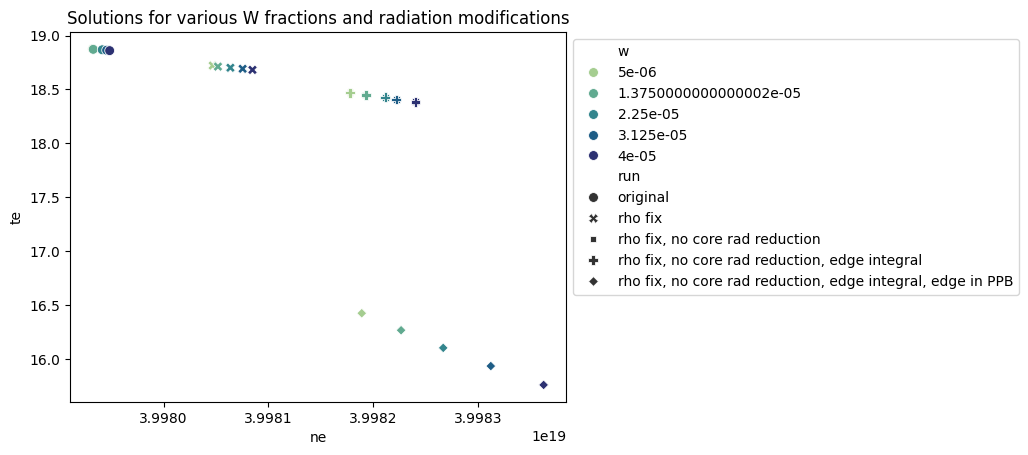

In [12]:
%matplotlib inline
sol_df = pd.DataFrame(sol_data)
sol_df = sol_df[["w", "run", "te", "ne"]]

ax = sns.scatterplot(
    data=sol_df, x="ne", y="te", hue="w", style="run", palette="crest", s=50
)
ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0), useOffset=False)
sns.move_legend(ax, loc="upper left", bbox_to_anchor=(1.0, 1.0))
ax.set_title("Solutions for various W fractions and radiation modifications")

Difficult to visualise due to overplotting: separate plots.

Text(0.5, 1.0, 'Solutions for various W fractions and radiation modifications')

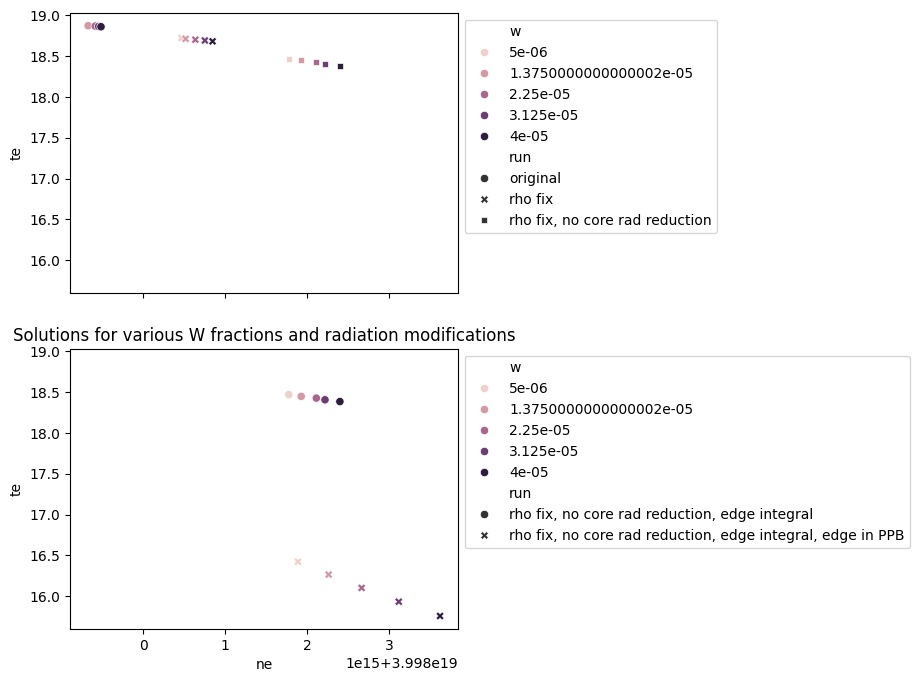

In [5]:
%matplotlib inline
fig, axs = plt.subplots(nrows=2, sharex=True, sharey=True)
fig.set_size_inches(5, 8)
sol_df_1 = sol_df[
    sol_df["run"].isin(["original", "rho fix", "rho fix, no core rad reduction"])
]
ax = sns.scatterplot(data=sol_df_1, x="ne", y="te", hue="w", style="run", ax=axs[0])
sns.move_legend(ax, loc="upper left", bbox_to_anchor=(1.0, 1.0))

sol_df_2 = sol_df[
    sol_df["run"].isin(
        [
            "rho fix, no core rad reduction, edge integral",
            "rho fix, no core rad reduction, edge integral, edge in PPB",
        ]
    )
]
ax = sns.scatterplot(data=sol_df_2, x="ne", y="te", hue="w", style="run", ax=axs[1])
sns.move_legend(ax, loc="upper left", bbox_to_anchor=(1.0, 1.0))
ax.set_title("Solutions for various W fractions and radiation modifications")

## Solution experiment: solve for edge in PPB
Fiddle with conditions to get the PPB to solve when the edge rad is included in the PPB.

In [15]:
INPUT_FILE = "data/lt_tau_alpha_sol_solve_IN.DAT"
# Solve Process each time after modifying W fraction
single_run = SingleRun(INPUT_FILE)
process.data_structure.impurity_radiation_module.f_nd_impurity_electron_array[13] = 5e-5

# Modifications for each run
# Try to get results for sensible te, ne and W
process.data_structure.physics_variables.te = 10.0
process.data_structure.physics_variables.dene = 4.0e19

impurity_radiation.rho_fix = True
process.data_structure.impurity_radiation_module.f_p_plasma_core_rad_reduction = 1.0
impurity_radiation.int_edge_rad = True
process.data_structure.physics_variables.i_rad_loss = 0

# Try turning up heating
process.data_structure.current_drive_variables.p_hcd_primary_extra_heat_mw = 200.0

single_run.run()

dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
Ratio of central solenoid overall current density at beginning of flat-top / end of flat-top > 1 (|f_j_cs_start_end_flat_top| > 1)
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, force

The IN.DAT file does not contain any obsolete variables.
 
**************************************************************************************************************
************************************************** PROCESS ***************************************************
************************************** Power Reactor Optimisation Code ***************************************
**************************************************************************************************************
 
Version : 3.2.0
Git Tag : 
Git Branch : 
Date : 08/10/2025 UTC
Time : 08:14
User : jon
Computer : jon-Precision-3560
Directory : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_3
Input : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_3/data/lt_tau_alpha_sol_solve_IN.DAT
Run title : generic large tokamak
Run type : Reactor concept design: Pulsed tokamak model, (c) UK Atomic Energy Authority
 
*************************************************************

dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommod

znfuel = 3.677714230762046e+19
znfuel = 3.677354219665755e+19
znfuel = 3.677377529402261e+19
znfuel = 3.6773760201631994e+19
znfuel = 3.677376117882143e+19
znfuel = 3.677376111555119e+19
znfuel = 3.6773761119647756e+19
znfuel = 3.6773761119382516e+19
PPB = {cc}
x = array([1.53574591, 0.99961972])
znfuel = 3.6790971259059302e+19
znfuel = 3.697873782128793e+19
znfuel = 3.69675887769616e+19
znfuel = 3.696825097597167e+19
znfuel = 3.696821164527737e+19
znfuel = 3.696821398128987e+19
znfuel = 3.696821384254445e+19
znfuel = 3.696821385078512e+19


dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommod

...

znfuel = 3.694596795490902e+19
PPB = {cc}
x = array([1.55493028, 0.99960605])
znfuel = 3.694596731221614e+19
znfuel = 3.694596737952735e+19
PPB = {cc}
x = array([1.55493025, 0.99960606])
znfuel = 3.694596802693505e+19
znfuel = 3.694596795894693e+19
PPB = {cc}
x = array([1.55493027, 0.99960606])
znfuel = 3.6945967952380895e+19
znfuel = 3.6945967927200375e+19
znfuel = 3.694596792871194e+19
znfuel = 3.6945967928621195e+19
PPB = {cc}
x = array([1.55493025, 0.99960608])
znfuel = 3.694596850276583e+19
znfuel = 3.694596843131296e+19
znfuel = 3.694596843560217e+19
znfuel = 3.6945968435344695e+19
PPB = {cc}
x = array([1.55493029, 0.99960604])
znfuel = 3.694596712167755e+19
znfuel = 3.6945967296636805e+19
znfuel = 3.694596728613425e+19
znfuel = 3.69459672867647e+19
PPB = {cc}
x = array([1.55493038, 0.999606  ])
znfuel = 3.694596580395398e+19
znfuel = 3.6945965959257735e+19


dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommod

znfuel = 3.6945965949935075e+19
znfuel = 3.69459659504947e+19
PPB = {cc}
x = array([1.55493055, 0.99960593])
znfuel = 3.694596298492491e+19
znfuel = 3.6945963295527625e+19
znfuel = 3.694596327688261e+19
znfuel = 3.694596327800184e+19
PPB = {cc}
x = array([1.55493029, 0.99960604])
znfuel = 3.694596772624156e+19
znfuel = 3.694596726034394e+19
znfuel = 3.694596728831107e+19
znfuel = 3.694596728663225e+19
PPB = {cc}
x = array([1.5549304, 0.999606 ])
znfuel = 3.694596580212511e+19
znfuel = 3.6945965931561755e+19
PPB = {cc}
x = array([1.55493038, 0.99960602])
znfuel = 3.6945966497931035e+19
znfuel = 3.694596642694491e+19
znfuel = 3.694596643120611e+19
znfuel = 3.694596643095032e+19
PPB = {cc}
x = array([1.55493038, 0.999606  ])
znfuel = 3.694596586039553e+19
znfuel = 3.694596595752409e+19
znfuel = 3.6945965951693595e+19


dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
dr_tf_plasma_case to small to accommodate the WP, forced to minimum value
Central density is less than pedestal density
dr_tf_plasma_case to small to accommodate the WP, forced to minimu

znfuel = 3.694596595204359e+19
PPB = {cc}
x = array([1.55493037, 0.999606  ])
znfuel = 3.694596595491612e+19
znfuel = 3.694596595461433e+19
PPB = {cc}
x = array([1.55493038, 0.999606  ])
znfuel = 3.694596595329261e+19
znfuel = 3.694596595343185e+19
PPB = {cc}
x = array([1.55493038, 0.999606  ])
znfuel = 3.694596595384648e+19
znfuel = 3.6945965953802674e+19
PPB = {cc}
znfuel = 3.69459659538053e+19
znfuel = 3.694596595380515e+19
PPB = {cc}
 
************************************ PROCESS found a consistent solution *************************************
 
PPB = {cc}
Running fixed-point problem for beta
znfuel = 3.694596595380516e+19
beta FPP iteration
beta = array(0.01796766)
beta_calc = 0.017967661733042317
beta - beta_calc = -3.469446951953614e-18
znfuel = 3.694596595380516e+19
beta FPP iteration
beta = 0.017967661733042317
beta_calc = 0.017967661733042317
beta - beta_calc = 0.0
PPB = {cc}
******************************************** Errors and Warnings ***********************************

PPB couldn't be solved with edge rad included. Increase aux heating to 200 MW, now can. Also needed right combination of te, ne to get solutions for all radiation modifications across all W fractions.

## Model failures due to negative n_i
During the above investigation, model failures occurred regularly. This was because of negative ion densities. Watch what happens during solve as fuel ion density goes negative, using csv output on each iteration.

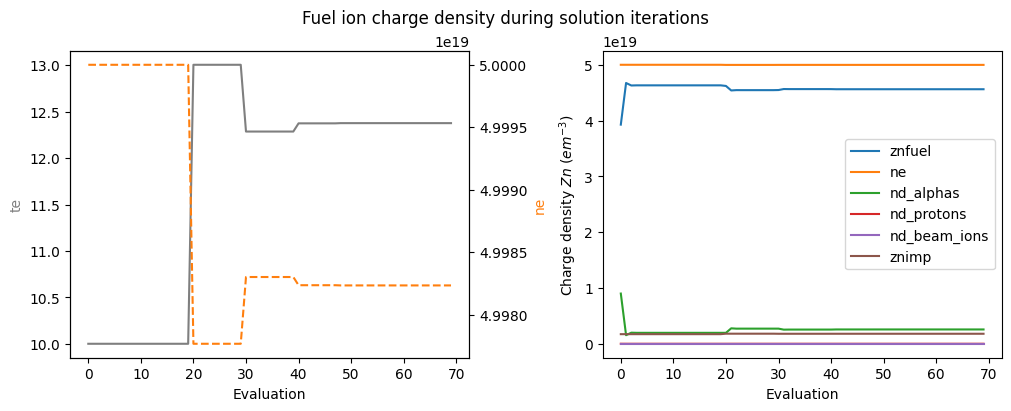

In [140]:
# Remove previous run's output
Path.unlink("znfuel.csv")

INPUT_FILE = "data/lt_tau_alpha_sol_solve_IN.DAT"
# Solve Process each time after modifying W fraction
single_run = SingleRun(INPUT_FILE)
process.data_structure.impurity_radiation_module.f_nd_impurity_electron_array[13] = 5e-6

# Modifications for each run
# Try to get results for sensible te, ne and W
process.data_structure.physics_variables.te = 10.0
# Moving 5-6 is the difference between convergence and not
process.data_structure.physics_variables.dene = 5.0e19

impurity_radiation.rho_fix = True
process.data_structure.impurity_radiation_module.f_p_plasma_core_rad_reduction = 1.0
impurity_radiation.int_edge_rad = True
process.data_structure.physics_variables.i_rad_loss = 0

# Try turning up heating
process.data_structure.current_drive_variables.p_hcd_primary_extra_heat_mw = 200.0

# Want to trigger nan in model
try:
    single_run.run()
except ValueError as e:
    print(e)
# else:
#     raise Exception
clear_output()

n_fuel_df = pd.read_csv("znfuel.csv")
n_fuel_df

# Plotting
fig, axs = plt.subplots(ncols=2, layout="constrained")
ax00 = axs[0].twinx()
ax01 = sns.lineplot(data=n_fuel_df["te"], ax=axs[0], dashes=False, c="C7")
ax01.set_xlabel("Evaluation")
ax01.set_ylabel("te", c="C7")
ax00 = sns.lineplot(data=n_fuel_df["ne"], ax=ax00, c="C1")
ax00.lines[0].set_linestyle("--")
ax00.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useOffset=False)
ax00.set_ylabel("ne", c="C1")

fig.set_size_inches(10, 4)
ax1 = sns.lineplot(data=n_fuel_df.drop(columns=["te"]), dashes=False, ax=axs[1])
ax1.set_xlabel("Evaluation")
ax1.set_ylabel("Charge density $Zn$ $(e m^{-3})$")

fig.suptitle("Fuel ion charge density during solution iterations")
FIG_DIR = Path.home() / "Desktop/figs"
fig.savefig(FIG_DIR / "fuel_ion_den_sol.png")

Change ne from 5-6e19.

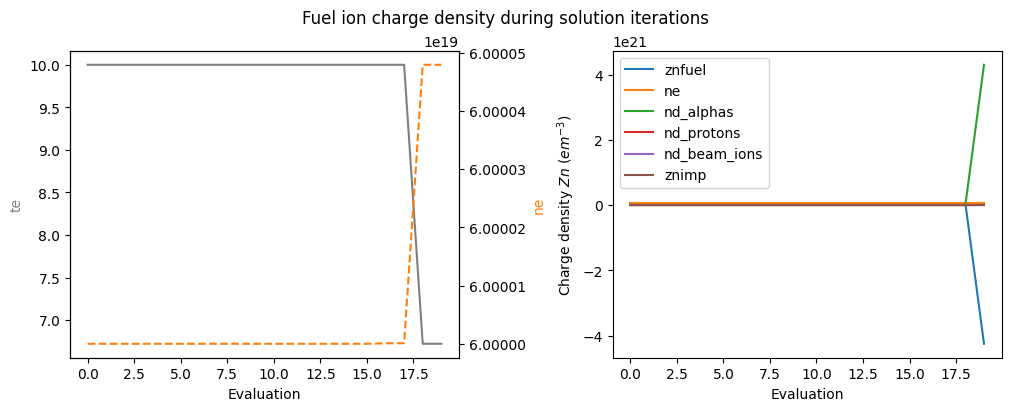

In [141]:
# Remove previous run's output
Path.unlink("znfuel.csv")

INPUT_FILE = "data/lt_tau_alpha_sol_solve_IN.DAT"
# Solve Process each time after modifying W fraction
single_run = SingleRun(INPUT_FILE)
process.data_structure.impurity_radiation_module.f_nd_impurity_electron_array[13] = 5e-6

# Modifications for each run
# Try to get results for sensible te, ne and W
process.data_structure.physics_variables.te = 10.0
# Moving 5-6 is the difference between convergence and not
process.data_structure.physics_variables.dene = 6.0e19

impurity_radiation.rho_fix = True
process.data_structure.impurity_radiation_module.f_p_plasma_core_rad_reduction = 1.0
impurity_radiation.int_edge_rad = True
process.data_structure.physics_variables.i_rad_loss = 0

# Try turning up heating
process.data_structure.current_drive_variables.p_hcd_primary_extra_heat_mw = 200.0

# Want to trigger nan in model
try:
    single_run.run()
except ValueError as e:
    print(e)
# else:
#     raise Exception
clear_output()

n_fuel_df = pd.read_csv("znfuel.csv")
n_fuel_df

# Plotting
fig, axs = plt.subplots(ncols=2, layout="constrained")
ax00 = axs[0].twinx()
ax01 = sns.lineplot(data=n_fuel_df["te"], ax=axs[0], dashes=False, c="C7")
ax01.set_xlabel("Evaluation")
ax01.set_ylabel("te", c="C7")
ax00 = sns.lineplot(data=n_fuel_df["ne"], ax=ax00, c="C1")
ax00.lines[0].set_linestyle("--")
ax00.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useOffset=False)
ax00.set_ylabel("ne", c="C1")

fig.set_size_inches(10, 4)
ax1 = sns.lineplot(data=n_fuel_df.drop(columns=["te"]), dashes=False, ax=axs[1])
ax1.set_xlabel("Evaluation")
ax1.set_ylabel("Charge density $Zn$ $(e m^{-3})$")

fig.suptitle("Fuel ion charge density during solution iterations")
FIG_DIR = Path.home() / "Desktop/figs"
fig.savefig(FIG_DIR / "fuel_ion_den_fail.png")

On changing the initial ne from 5-6e19, the solver moves in different directions: higher te (13) converges in the former case, lower te (7) causes negative nd fuel ions and model error. Found a solver knifedge?

## Solution vector movement
Check how solution vector varies based on initial vector.

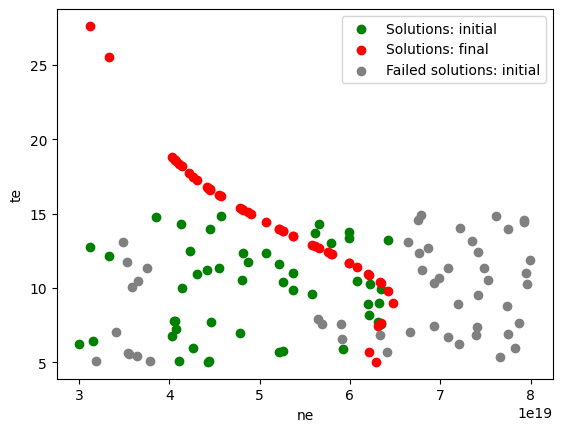

In [188]:
sol_data = {
    "te_init": [],
    "ne_init": [],
    "te_sol": [],
    "ne_sol": [],
}
INPUT_FILE = "data/lt_tau_alpha_sol_solve_IN.DAT"

N = 100
rng = np.random.default_rng()
tes = rng.uniform(low=5.0, high=15.0, size=N)
nes = rng.uniform(low=3.0e19, high=8.0e19, size=N)

for i in range(N):
    # Set up
    single_run = SingleRun(INPUT_FILE)
    process.data_structure.impurity_radiation_module.f_nd_impurity_electron_array[
        13
    ] = 5.0e-6
    process.data_structure.current_drive_variables.p_hcd_primary_extra_heat_mw = 300.0
    impurity_radiation.rho_fix = True
    process.data_structure.impurity_radiation_module.f_p_plasma_core_rad_reduction = 1.0
    impurity_radiation.int_edge_rad = True
    process.data_structure.physics_variables.i_rad_loss = 0

    # Modifications for each run
    process.data_structure.physics_variables.te = tes[i]
    process.data_structure.physics_variables.dene = nes[i]

    try:
        # Handle failed runs
        single_run.run()
    except Exception:
        # Insert nans for everything on failure, then add back inputs
        for key in sol_data.keys():
            sol_data[key].append(np.nan)
        sol_data["te_init"][-1] = tes[i]
        sol_data["ne_init"][-1] = nes[i]
        continue

    sol_data["te_init"].append(tes[i])
    sol_data["ne_init"].append(nes[i])
    sol_data["te_sol"].append(process.data_structure.physics_variables.te)
    sol_data["ne_sol"].append(process.data_structure.physics_variables.dene)

# Clear the lengthy stdout from multiple process runs
clear_output()

sol_df = pd.DataFrame(sol_data)
fig, ax = plt.subplots()
# Filter initial points that didn't converge
sols = sol_df[sol_df["te_sol"].notnull()]
failed_sols = sol_df[sol_df["te_sol"].isnull()]
ax.scatter(sols["ne_init"], sols["te_init"], c="green", label="Solutions: initial")
ax.scatter(sols["ne_sol"], sols["te_sol"], c="red", label="Solutions: final")
ax.scatter(
    failed_sols["ne_init"],
    failed_sols["te_init"],
    c="grey",
    label="Failed solutions: initial",
)
ax.set_xlabel("ne")
ax.set_ylabel("te")
ax.legend()

## Plot response surfaces of PPB and tau_alpha constraints

In [269]:
INPUT_FILE = "data/lt_tau_alpha_sol_eval_IN.DAT"


def eval_cons(ne, te):
    # Set up
    single_run = SingleRun(INPUT_FILE)
    process.data_structure.impurity_radiation_module.f_nd_impurity_electron_array[
        13
    ] = 5.0e-6
    process.data_structure.current_drive_variables.p_hcd_primary_extra_heat_mw = 300.0
    impurity_radiation.rho_fix = True
    process.data_structure.impurity_radiation_module.f_p_plasma_core_rad_reduction = 1.0
    impurity_radiation.int_edge_rad = True
    process.data_structure.physics_variables.i_rad_loss = 0

    # Modifications for each run
    process.data_structure.physics_variables.dene = ne
    process.data_structure.physics_variables.te = te

    try:
        # Handle failed runs
        single_run.run()
    except Exception:
        return None, None

    con2_value = process.constraints.constraint_equation_2().normalised_residual
    con62_value = process.constraints.constraint_equation_62().normalised_residual
    return con2_value, con62_value


N = 10
ne = np.linspace(3.0e19, 8.0e19, num=N)
te = np.linspace(5.0, 15.0, num=N)
ne_grid, te_grid = np.meshgrid(ne, te)
eval_cons_vec = np.vectorize(pyfunc=eval_cons)
con2, con62 = eval_cons_vec(ne_grid, te_grid)
# Clear the lengthy stdout from multiple process runs
clear_output()

In [270]:
cons_results = np.array(
    [ne_grid.flatten(), te_grid.flatten(), con2.flatten(), con62.flatten()]
)
cons_df = pd.DataFrame(
    {
        "te": cons_results[0],
        "ne": cons_results[1],
        "ppb": cons_results[2],
        "tau_alpha": cons_results[3],
    }
)
cons_df


,te,ne,ppb,tau_alpha
0,3.000000e+19,5.0,0.511635,2.231548e-14
1,3.555556e+19,5.0,0.474388,1.199041e-14
2,4.111111e+19,5.0,0.410219,3.674838e-14
3,4.666667e+19,5.0,0.321850,1.575406e-13
4,5.222222e+19,5.0,0.214956,1.010636e-12
...,...,...,...,...
95,5.777778e+19,15.0,-0.089537,3.939604e-10
96,6.333333e+19,15.0,-0.129316,5.692924e-11
97,6.888889e+19,15.0,-0.156596,4.987122e-13
98,7.444444e+19,15.0,-0.166026,3.659517e-12


In [271]:
cons_df = cons_df.dropna()
cons_df

,te,ne,ppb,tau_alpha
0,3.000000e+19,5.0,0.511635,2.231548e-14
1,3.555556e+19,5.0,0.474388,1.199041e-14
2,4.111111e+19,5.0,0.410219,3.674838e-14
3,4.666667e+19,5.0,0.321850,1.575406e-13
4,5.222222e+19,5.0,0.214956,1.010636e-12
...,...,...,...,...
94,5.222222e+19,15.0,-0.037368,3.437388e-10
95,5.777778e+19,15.0,-0.089537,3.939604e-10
96,6.333333e+19,15.0,-0.129316,5.692924e-11
97,6.888889e+19,15.0,-0.156596,4.987122e-13


/tmp/ipykernel_510431/1515931528.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend()
/tmp/ipykernel_510431/1515931528.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend()


Text(0.5, 0.98, 'Constraint evaluations')

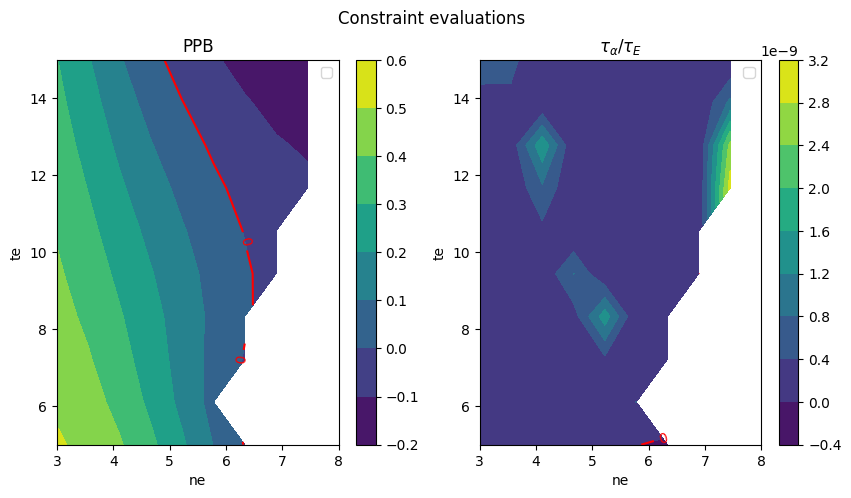

In [280]:
fig, axs = plt.subplots(ncols=2)
fig.set_size_inches(10, 5)
contour = axs[0].contourf(
    (ne_grid * 1e-19),
    te_grid,
    con2,
)
fig.colorbar(contour, ax=axs[0])
axs[0].set_xlabel("ne")
axs[0].set_ylabel("te")
axs[0].legend()
cs = axs[0].contour(
    (ne_grid * 1e-19),
    te_grid,
    con2,
    levels=[0.0],
    colors="red",
)
axs[0].clabel(cs)
# Second plot
contour = axs[1].contourf(
    (ne_grid * 1e-19),
    te_grid,
    con62,
)
fig.colorbar(contour, ax=axs[1])
axs[1].set_xlabel("ne")
axs[1].set_ylabel("te")
axs[1].legend()
cs = axs[1].contour(
    (ne_grid * 1e-19),
    te_grid,
    con62,
    levels=[0.0],
    colors="red",
)
axs[1].clabel(cs)
axs[0].set_title("PPB")
axs[1].set_title(r"$\tau_\alpha / \tau_E$")
fig.suptitle("Constraint evaluations")

Check tau_alpha constraint: values are all tiny.

Constraint and plasma_composition() have the same equation. Check equations here: cyclical?

Yes, plasma_composition() nd_alpha calc uses tau_alpha / tau_E = 5 eqn: cyclical. Need alternative eqn for n_alpha.